In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [2]:
df = sns.load_dataset('titanic')

In [3]:
df.shape

(891, 15)

In [5]:
df.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


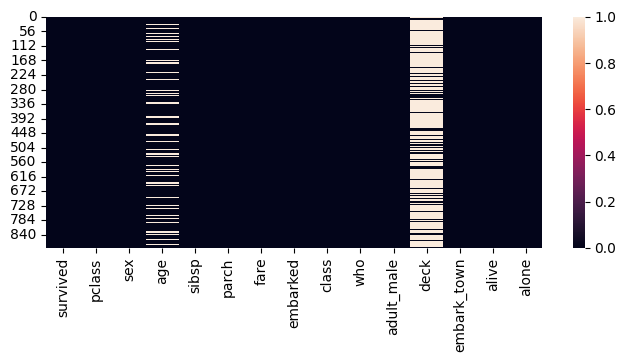

In [6]:
plt.figure( figsize=(8,3) )
sns.heatmap(df.isnull())
plt.show()

In [7]:
df = df.drop(columns=['deck'])
df = df.ffill()

In [8]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True


In [11]:
# Feature Engineering
df = df.drop(columns=['alive','class','who','adult_male','embark_town','alone']) 
df.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C


In [12]:
# Divide Data into X(Input) and y(labels)
X = df.drop(columns=['survived'])
y = df['survived']

In [14]:
X.head(3)

,pclass,sex,age,sibsp,parch,fare,embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S


In [15]:
y.head(3)

0    0
1    1
2    1
Name: survived, dtype: int64

In [18]:
# We need to encode "sex" and "embarked" column
X.head(2)

,pclass,sex,age,sibsp,parch,fare,embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C


In [24]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    891 non-null    int64  
 1   sex       891 non-null    object 
 2   age       891 non-null    float64
 3   sibsp     891 non-null    int64  
 4   parch     891 non-null    int64  
 5   fare      891 non-null    float64
 6   embarked  891 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 48.9+ KB


In [29]:
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].map(lambda val: list(X[col].unique()).index(val))

In [30]:
X.head(2)

,pclass,sex,age,sibsp,parch,fare,embarked
0,3,0,22.0,1,0,7.2500,0
1,1,1,38.0,1,0,71.2833,1


In [35]:
from sklearn.preprocessing import MinMaxScaler

In [36]:
scaler = MinMaxScaler()

In [37]:
# We need to perform scaling on "age" and "fare" columns  (Normalization [0-1])
for col in X.select_dtypes(include=float).columns:
    X[col] = scaler.fit_transform(X[[col]])

In [38]:
X.head(3)

,pclass,sex,age,sibsp,parch,fare,embarked
0,3,0,0.271174,1,0,0.014151,0
1,1,1,0.472229,1,0,0.139136,1
2,3,1,0.321438,0,0,0.015469,0


In [41]:
from sklearn.model_selection import train_test_split

In [42]:
# Divide Dataset into train and test
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20 , random_state=42)

In [39]:
from sklearn.linear_model import LogisticRegression

In [40]:
model = LogisticRegression()

In [43]:
model.fit( X_train,y_train )

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [47]:
y_pred = model.predict(X_test)

In [48]:
from sklearn.metrics import accuracy_score

In [49]:
accuracy_score(y_test,y_pred)*100

79.3296089385475